# Dynamic Programming — Finite-Horizon Toy Notebook (Variant 2)

This notebook teaches five core ideas using one small, fully enumerable inventory control problem.

| Concept | Plain-English meaning |
| --- | --- |
| Dynamic programming | break a sequential problem into one-step sub-problems solved backward |
| Bellman equation | immediate net cost + best expected future value |
| Backward induction | solve from the terminal time back to the start |
| Value function | best achievable expected future performance from each state-time pair |
| Optimal policy extraction | at each state-time pair, choose the action that wins the Bellman comparison |

The problem is intentionally tiny so that every state, every action, and every demand outcome can be enumerated and printed explicitly.

**Key differences from Variant 1:** shorter horizon ($T=3$), binary order action ($x \in \{0,1\}$), revised demand distribution ($P(D=0)=0.4,\ P(D=1)=0.3,\ P(D=2)=0.3$), an explicit sales-revenue term in the one-step cost, and a lower shortage penalty ($C_{\text{short}}=2.0$).


## Section 1 — Problem setup

### Plain-English story

We manage a small inventory over a short planning horizon.
Each period we decide whether to order one unit or nothing.
Random demand then arrives.
We pay for what we order, for leftover stock we hold overnight, and for any demand we cannot satisfy.
We also earn **sales revenue** on every unit we sell to a customer.
At the end, remaining inventory has a residual holding cost.

### Model parameters

| Element | Symbol | Choices |
| --- | --- | --- |
| Planning horizon | $T$ | 3 periods |
| Inventory state | $s_t$ | $\{0,1,2,3\}$ |
| Order quantity | $x_t$ | $\{0,1\}$ |
| Inventory cap | $S_{\max}$ | 3 units |
| Demand | $D_{t+1}$ | $\{0,1,2\}$ with $P(D=0)=0.4,\ P(D=1)=0.3,\ P(D=2)=0.3$ |

### Transition rule

$$y_t = \min(s_t + x_t,\ S_{\max}) \qquad \text{(post-order inventory)}$$
$$s_{t+1} = \max(y_t - D_{t+1},\ 0)$$

### One-step cost

$$c(s_t, x_t, D_{t+1}) = \underbrace{1.0 \cdot x_t}_{\text{order cost}} + \underbrace{0.6 \cdot s_{t+1}}_{\text{holding cost}} + \underbrace{2.0 \cdot \max(D_{t+1} - y_t,\ 0)}_{\text{shortage penalty}} - \underbrace{1.5 \cdot \min(y_t,\ D_{t+1})}_{\text{sales revenue}}$$

The **sales revenue** term $-1.5 \cdot \min(y_t, D_{t+1})$ reduces the one-step cost.
Each unit of satisfied demand earns 1.5 in revenue.
The net one-step cost can therefore be negative (profitable period).

### Terminal condition

$$V_T(s) = 0.5 \cdot s \qquad \text{(residual holding cost on leftover stock)}$$

### Why this is small enough for exact DP

- 4 states $\times$ 4 time points = 16 state-time nodes
- at most 2 feasible actions per node
- 3 demand outcomes per action

Every path through this problem is enumerable.
We can therefore compute exact optimal values and exact optimal actions — no approximation needed.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
np.set_printoptions(precision=3, suppress=True)

SEED = 20260417

# Model constants
T       = 3                               # planning horizon
S_MAX   = 3                               # maximum inventory cap
STATES  = np.arange(S_MAX + 1)            # {0, 1, 2, 3}
ACTIONS = np.array([0, 1])                # order quantities (binary)

DEMAND_SUPPORT = np.array([0, 1, 2])
DEMAND_PROBS   = np.array([0.4, 0.3, 0.3])

C_ORDER = 1.0   # cost per unit ordered
C_HOLD  = 0.6   # cost per unit held overnight
C_SHORT = 2.0   # penalty per unit of unsatisfied demand
C_SELL  = 1.5   # revenue per unit of satisfied demand (reduces costs)
C_TERM  = 0.5   # terminal residual holding cost per unit

assert np.all(DEMAND_PROBS >= 0.0)
assert np.isclose(DEMAND_PROBS.sum(), 1.0)

print(f'Horizon T = {T}')
print(f'State space S = {STATES.tolist()}')
print(f'Action grid A = {ACTIONS.tolist()}')
print(f'Demand support = {DEMAND_SUPPORT.tolist()}')
print(f'Demand probs   = {DEMAND_PROBS.tolist()}')
print(f'Costs: order={C_ORDER}, hold={C_HOLD}, shortage={C_SHORT}, terminal={C_TERM}')
print(f'Revenue: sell={C_SELL} per unit satisfied')


Horizon T = 3
State space S = [0, 1, 2, 3]
Action grid A = [0, 1]
Demand support = [0, 1, 2]
Demand probs   = [0.4, 0.3, 0.3]
Costs: order=1.0, hold=0.6, shortage=2.0, terminal=0.5
Revenue: sell=1.5 per unit satisfied


## Section 2 — Why dynamic programming is needed

### The problem is sequential

Each period's order decision affects next period's starting inventory, which affects costs in all future periods.
A decision made today has a downstream echo through inventory levels all the way to the horizon.

### Myopic thinking can fail

Suppose we are in state $s=0$ at time $t=0$.
A myopic view says: ordering is expensive, so order as little as possible.
But if we do not order now, we risk high shortage penalties in future periods and start those periods from a weaker position.

The right answer depends on the entire cost structure across all future periods, not just the immediate one.

### What dynamic programming does

Dynamic programming solves this by working backward from the end of the horizon:

1. At period $T$, the future is empty — there is only the terminal cost.
2. At period $T-1$, we know what period-$T$ states are worth, so we can judge each action correctly.
3. We continue backward to period $0$.

At each step we combine an immediate cost with an already-computed future value.
That combination is the Bellman equation.

### How DP differs from two other approaches

| Approach | What it does | Gives exact optimal? |
| --- | --- | --- |
| Direct heuristic rule | prescribes an action without optimization | not in general |
| Monte Carlo simulation | evaluates a given policy by averaging many rollouts | no — it evaluates, not optimizes |
| Dynamic programming | computes exact optimal value and policy via backward recursion | yes, in finite exact models |

## Section 3 — Bellman equation

### The recursion

For a cost-minimization problem the finite-horizon Bellman recursion is:

$$\boxed{V_t(s) = \min_{x \in \mathcal{X}(s)}\ \mathbb{E}\bigl[c(s,\, x,\, D_{t+1}) + V_{t+1}(s')\bigr]}$$

with terminal condition $V_T(s) = 0.5 \cdot s$.

### Symbol-by-symbol explanation

| Symbol | Plain-English meaning |
| --- | --- |
| $V_t(s)$ | best achievable expected total net cost from time $t$ onward, starting at inventory $s$ |
| $\mathcal{X}(s)$ | feasible order quantities from state $s$ |
| $x$ | current order quantity |
| $D_{t+1}$ | random demand in the next period |
| $c(s,x,D_{t+1})$ | one-step net cost: order + holding + shortage − sales revenue |
| $s'$ | next-period inventory after ordering $x$ and seeing demand $D_{t+1}$ |
| $V_{t+1}(s')$ | best expected future net cost starting from $s'$ at time $t+1$ |
| $\min_x$ | choose the order quantity that makes the total smallest |
| $\mathbb{E}[\cdot]$ | average over all possible demand realizations |

### The key decomposition

$$V_t(s) = \min_x \underbrace{\mathbb{E}\bigl[c(s,x,D_{t+1})\bigr]}_{\text{expected net immediate cost}} + \underbrace{\mathbb{E}\bigl[V_{t+1}(s')\bigr]}_{\text{expected best future value}}$$

The net immediate cost combines order cost, holding cost, and shortage penalty, minus the sales revenue earned on satisfied demand.
Once $V_{t+1}$ is known, computing $V_t$ is a single-step expectation plus a minimization.
This is what makes backward induction tractable.


In [6]:
# Core model functions

def feasible_actions(s):
    # Order quantities x such that s + x <= S_MAX
    return [int(a) for a in ACTIONS if s + a <= S_MAX]


def transition(s, x, d):
    # Next inventory after ordering x and observing demand d
    post_order = min(s + x, S_MAX)
    return max(post_order - d, 0)


def immediate_cost(s, x, d):
    # One-step net cost: order cost + holding cost + shortage penalty − sales revenue
    post_order = min(s + x, S_MAX)
    next_s     = max(post_order - d, 0)
    shortage   = max(d - post_order, 0)
    units_sold = min(post_order, d)
    return C_ORDER * x + C_HOLD * next_s + C_SHORT * shortage - C_SELL * units_sold


def terminal_value(s):
    # Terminal residual cost at time T
    return C_TERM * s


def bellman_value_for_action(s, x, V_next):
    # Expected Bellman value for one (state, action) pair given V_next
    total = 0.0
    for d, p in zip(DEMAND_SUPPORT, DEMAND_PROBS):
        ns    = transition(s, x, int(d))
        total += p * (immediate_cost(s, x, int(d)) + V_next[ns])
    return total


def bellman_breakdown(s, x, V_next):
    # Row-by-row breakdown for one (state, action) pair
    rows, total = [], 0.0
    for d, p in zip(DEMAND_SUPPORT, DEMAND_PROBS):
        d   = int(d)
        ns  = transition(s, x, d)
        ic  = immediate_cost(s, x, d)
        fv  = V_next[ns]
        w   = float(p) * (ic + fv)
        rows.append({'d': d, 'p': float(p), 'next_s': ns,
                     'immediate': ic, 'future': fv,
                     'total': ic + fv, 'weighted': w})
        total += w
    return rows, total


# Quick sanity check
print('feasible_actions(0) =', feasible_actions(0))
print('feasible_actions(2) =', feasible_actions(2))
print('feasible_actions(3) =', feasible_actions(3))   # s=3 can only order 0
print('transition(s=1, x=1, d=1) =', transition(1, 1, 1))
print('immediate_cost(s=1, x=1, d=1) =', immediate_cost(1, 1, 1))
print('  (order 1.0  +  hold 0.6*1=0.6  +  short 0.0  -  sell 1.5 =', 1.0 + 0.6 + 0.0 - 1.5, ')')


feasible_actions(0) = [0, 1]
feasible_actions(2) = [0, 1]
feasible_actions(3) = [0]
transition(s=1, x=1, d=1) = 1
immediate_cost(s=1, x=1, d=1) = 0.10000000000000009
  (order 1.0  +  hold 0.6*1=0.6  +  short 0.0  -  sell 1.5 = 0.10000000000000009 )


## Section 4 — One-step Bellman calculation by hand

Before running the full algorithm, we work through one cell of the value table manually.

We pick: $t = 1,\quad s = 1.$

To evaluate actions at $t=1$ we need $V_2$.
We derive $V_2$ from the terminal row $V_3$ by one backward step first.

Then, for each feasible action $x \in \mathcal{X}(s=1)$:

1. Enumerate all three demand outcomes $d \in \{0,1,2\}$.
2. Compute the next state $s'$.
3. Compute the net immediate cost $c(s,x,d)$ (including the sales revenue term).
4. Look up the future value $V_2(s')$.
5. Form immediate + future for each demand outcome.
6. Average over demand probabilities.
7. Compare actions and choose the best.

**This is a _local_ Bellman evaluation — it solves exactly one cell $(t=1, s=1)$ of the value table.**
Its result is $V_1(1)$ and the corresponding best action $x^*(1,1)$.
Later we will see that full backward induction repeats this same calculation for every cell.


Terminal value V_3(s): [0.  0.5 1.  1.5]
V_2(s) computed from V_3: [ 1.14  0.14 -0.14  0.96]
pi_2(s): [1 0 0 0]

--- Worked Bellman at (t=1, s=1) ---
Future values from V_2.  Feasible actions: [0, 1]

Action x = 0
    d |     p | next_s | net imm. |  future |   total |  weighted
  ---------------------------------------------------------
    0 |  0.40 |      1 |    0.600 |   0.140 |   0.740 |     0.296
    1 |  0.30 |      0 |   -1.500 |   1.140 |  -0.360 |    -0.108
    2 |  0.30 |      0 |    0.500 |   1.140 |   1.640 |     0.492
  => E[net cost + future] = 0.680

Action x = 1
    d |     p | next_s | net imm. |  future |   total |  weighted
  ---------------------------------------------------------
    0 |  0.40 |      2 |    2.200 |  -0.140 |   2.060 |     0.824
    1 |  0.30 |      1 |    0.100 |   0.140 |   0.240 |     0.072
    2 |  0.30 |      0 |   -2.000 |   1.140 |  -0.860 |    -0.258
  => E[net cost + future] = 0.638

=> V_1(1) = 0.638
=> x*(t=1, s=1) = 1


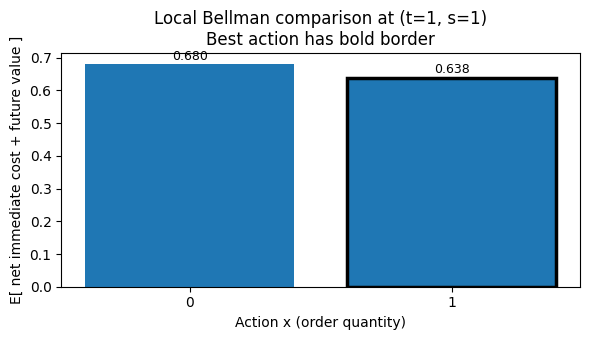

In [8]:
# Step 1: terminal value V_T
V_terminal = np.array([terminal_value(s) for s in STATES], dtype=float)
print('Terminal value V_3(s):', V_terminal)

# Step 2: one backward step to get V_2 from V_3 (terminal)
V2  = np.zeros(len(STATES), dtype=float)
pi2 = np.zeros(len(STATES), dtype=int)
for s in STATES:
    best_val, best_act = np.inf, 0
    for x in feasible_actions(int(s)):
        val = bellman_value_for_action(int(s), x, V_terminal)
        if val < best_val:
            best_val, best_act = val, x
    V2[s], pi2[s] = best_val, best_act

print('V_2(s) computed from V_3:', np.round(V2, 3))
print('pi_2(s):', pi2)

# Step 3: worked Bellman comparison at (t=1, s=1)
s_ex, t_ex = 1, 1
print(f'\n--- Worked Bellman at (t={t_ex}, s={s_ex}) ---')
print(f'Future values from V_2.  Feasible actions: {feasible_actions(s_ex)}\n')

action_ev = {}
for x in feasible_actions(s_ex):
    rows, ev = bellman_breakdown(s_ex, x, V2)
    action_ev[x] = ev
    print(f'Action x = {x}')
    print(f'  {"d":>3} | {"p":>5} | {"next_s":>6} | {"net imm.":>8} | {"future":>7} | {"total":>7} | {"weighted":>9}')
    print('  ' + '-' * 57)
    for r in rows:
        print(f'  {r["d"]:>3} | {r["p"]:>5.2f} | {r["next_s"]:>6} | '
              f'{r["immediate"]:>8.3f} | {r["future"]:>7.3f} | '
              f'{r["total"]:>7.3f} | {r["weighted"]:>9.3f}')
    print(f'  => E[net cost + future] = {ev:.3f}\n')

best_act_ex = min(action_ev, key=action_ev.get)
print(f'=> V_1({s_ex}) = {action_ev[best_act_ex]:.3f}')
print(f'=> x*(t={t_ex}, s={s_ex}) = {best_act_ex}')

# Bar chart of action Bellman values
acts = list(action_ev.keys())
vals = [action_ev[a] for a in acts]
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(acts, vals)
bars[acts.index(best_act_ex)].set_edgecolor('black')
bars[acts.index(best_act_ex)].set_linewidth(2.5)
ax.set_xlabel('Action x (order quantity)')
ax.set_ylabel('E[ net immediate cost + future value ]')
ax.set_title(f'Local Bellman comparison at (t={t_ex}, s={s_ex})\nBest action has bold border')
ax.set_xticks(acts)
for a, v in zip(acts, vals):
    ax.text(a, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


We also can pick any point of the grid the understand how the state-value is calculated using the Bellman-equation.

In [33]:
# ── PICK ANY STATE-TIME PAIR TO INSPECT ───────────────────────────────────
s_ex = 0
t_ex = 2

# ── Uses V[t_ex+1] from the full solved tables — works for any valid (s,t) ─
assert 0 <= t_ex < T,       f't_ex must be in [0, {T-1}]'
assert int(s_ex) in STATES,  f's_ex must be in {STATES.tolist()}'

V_next_ex  = V[t_ex + 1]
actions_ex = feasible_actions(int(s_ex))

print(f'--- Worked Bellman at (t={t_ex}, s={s_ex}) ---')
print(f'V[t+1] = {np.round(V_next_ex, 3).tolist()}')
print(f'Feasible actions: {actions_ex}\n')

action_ev = {}
for x in actions_ex:
    rows, ev = bellman_breakdown(int(s_ex), x, V_next_ex)
    action_ev[x] = ev
    print(f'Action x = {x}')
    print(f'  {"d":>3} | {"p":>5} | {"next_s":>6} | {"net imm.":>8} | {"future":>7} | {"total":>7} | {"weighted":>9}')
    print('  ' + '-' * 57)
    for r in rows:
        print(f'  {r["d"]:>3} | {r["p"]:>5.2f} | {r["next_s"]:>6} | '
              f'{r["immediate"]:>8.3f} | {r["future"]:>7.3f} | '
              f'{r["total"]:>7.3f} | {r["weighted"]:>9.3f}')
    print(f'  => E[net cost + future] = {ev:.3f}\n')

best_act = min(action_ev, key=action_ev.get)
print(f'V_{t_ex}({s_ex}) = {action_ev[best_act]:.3f}   '
      f'(matches full-table value {V[t_ex, int(s_ex)]:.3f})')
print(f'x*(t={t_ex}, s={s_ex}) = {best_act}')


--- Worked Bellman at (t=2, s=0) ---
V[t+1] = [0.0, 0.5, 1.0, 1.5]
Feasible actions: [0, 1]

Action x = 0
    d |     p | next_s | net imm. |  future |   total |  weighted
  ---------------------------------------------------------
    0 |  0.40 |      0 |    0.000 |   0.000 |   0.000 |     0.000
    1 |  0.30 |      0 |    2.000 |   0.000 |   2.000 |     0.600
    2 |  0.30 |      0 |    4.000 |   0.000 |   4.000 |     1.200
  => E[net cost + future] = 1.800

Action x = 1
    d |     p | next_s | net imm. |  future |   total |  weighted
  ---------------------------------------------------------
    0 |  0.40 |      1 |    1.600 |   0.500 |   2.100 |     0.840
    1 |  0.30 |      0 |   -0.500 |   0.000 |  -0.500 |    -0.150
    2 |  0.30 |      0 |    1.500 |   0.000 |   1.500 |     0.450
  => E[net cost + future] = 1.140

V_2(0) = 1.140   (matches full-table value 1.140)
x*(t=2, s=0) = 1


## Section 5 — Local Bellman evaluation vs. full backward induction

This section makes the most important conceptual distinction explicit.

---

### Local Bellman evaluation

What we just did in Section 4 is a **local Bellman calculation**:

- We fixed one time $t=2$ and one state $s=1$.
- We used a pre-computed $V_3$ to evaluate each action.
- We extracted $V_2(1)$ and $x^*(2,1)$.

That is **one cell** in the full value table.

---

### Full backward induction (the complete DP algorithm)

Backward induction applies the same local calculation to **every state at every time step**, going from $t=T-1$ back to $t=0$:

```
V[T]  <-- terminal condition

for t in [T-1, T-2, ..., 1, 0]:        # backward in time
    for s in {0, 1, 2, 3}:             # every state
        V[t,s]  = min_x  E[ c(s,x,D) + V[t+1, s'] ]
        pi[t,s] = argmin of the same expression
```

---

### The difference at a glance

| | What is solved | Result |
| --- | --- | --- |
| **Local Bellman evaluation** | one $(t,s)$ cell | $V_t(s)$ and $x^*(t,s)$ for that one cell |
| **Full backward induction** | all $(t,s)$ cells | complete value table and policy table |

**Local Bellman is the building block. Backward induction is the whole algorithm.**

Once backward induction finishes we have:
- `V[t, s]`: the best achievable expected total cost from each state-time pair
- `pi[t, s]`: the optimal order quantity at each state-time pair

These tables can then be executed forward.

In [10]:
def solve_dp():
    """Solve the full finite-horizon DP by backward induction.

    Returns
    -------
    V  : (T+1, n_states) float array of optimal values
    pi : (T,   n_states) int array of optimal actions
    """
    n  = len(STATES)
    V  = np.zeros((T + 1, n), dtype=float)
    pi = np.zeros((T,     n), dtype=int)

    # Terminal condition
    V[T] = np.array([terminal_value(s) for s in STATES], dtype=float)

    # Backward pass: T-1, T-2, ..., 1, 0
    for t in range(T - 1, -1, -1):
        for s in STATES:
            best_val, best_act = np.inf, 0
            for x in feasible_actions(int(s)):
                val = bellman_value_for_action(int(s), x, V[t + 1])
                if val < best_val:
                    best_val, best_act = val, x
            V[t,  s] = best_val
            pi[t, s] = best_act

    return V, pi


V, PI = solve_dp()

# Verification
print('Terminal row V[T] =', V[T])
print()
print('Full value table V[t, s]  (rows=time, cols=state):')
header = 't\\s | ' + '  '.join(f's={s}' for s in STATES)
print(header)
print('-' * len(header))
for t in range(T + 1):
    row = '  '.join(f'{V[t,s]:6.3f}' for s in STATES)
    print(f't={t} | {row}')

print()
print('Optimal policy table pi[t, s]:')
print(header)
print('-' * len(header))
for t in range(T):
    row = '  '.join(f'{PI[t,s]:6d}' for s in STATES)
    print(f't={t} | {row}')

# Confirm Section 4 hand calculation matches the full table
assert abs(V[t_ex, s_ex] - action_ev[best_act_ex]) < 1e-9
print(f'\nSanity check: V[{t_ex},{s_ex}] = {V[t_ex,s_ex]:.3f}  '
      f'(matches Section 4 hand value {action_ev[best_act_ex]:.3f})')

Terminal row V[T] = [0.  0.5 1.  1.5]

Full value table V[t, s]  (rows=time, cols=state):
t\s | s=0  s=1  s=2  s=3
------------------------
t=0 |  2.203   0.861  -0.139   0.110
t=1 |  1.680   0.638  -0.362   0.294
t=2 |  1.140   0.140  -0.140   0.960
t=3 |  0.000   0.500   1.000   1.500

Optimal policy table pi[t, s]:
t\s | s=0  s=1  s=2  s=3
------------------------
t=0 |      1       1       0       0
t=1 |      1       1       0       0
t=2 |      1       0       0       0

Sanity check: V[1,1] = 0.638  (matches Section 4 hand value 0.638)


## Section 6 — Visualizing the value table and policy table

Two key outputs of dynamic programming:

1. **Value table `V[t, s]`** — how costly (or advantageous) it is to be in state $s$ at time $t$.
   Higher inventory at an earlier time is generally a more advantageous position.

2. **Policy table `pi[t, s]`** — the optimal order quantity at each state-time pair.
   This is immediately executable: observe $(t, s)$, look up $\pi[t,s]$, order that amount.

Both tables are filled by the backward induction in Section 5.

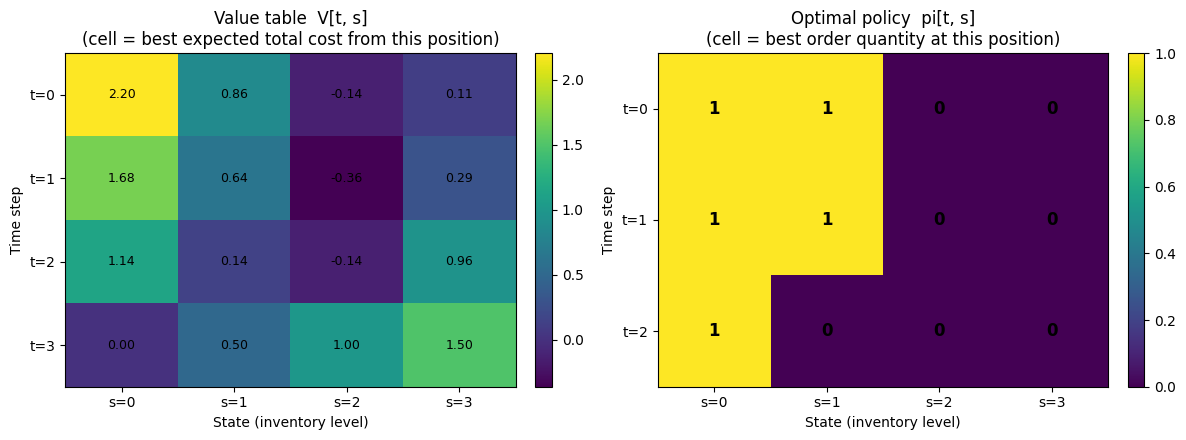

Key patterns to read:
  Value table : lower inventory -> higher cost (more shortage exposure)
  Policy table: lower inventory / more time remaining -> larger order quantity


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Value table heatmap
ax = axes[0]
im = ax.imshow(V, aspect='auto')
ax.set_xticks(range(len(STATES)))
ax.set_yticks(range(T + 1))
ax.set_xticklabels([f's={s}' for s in STATES])
ax.set_yticklabels([f't={t}' for t in range(T + 1)])
ax.set_xlabel('State (inventory level)')
ax.set_ylabel('Time step')
ax.set_title('Value table  V[t, s]\n(cell = best expected total cost from this position)')
for t in range(T + 1):
    for s in range(len(STATES)):
        ax.text(s, t, f'{V[t, s]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Policy table heatmap
ax = axes[1]
im2 = ax.imshow(PI.astype(float), aspect='auto')
ax.set_xticks(range(len(STATES)))
ax.set_yticks(range(T))
ax.set_xticklabels([f's={s}' for s in STATES])
ax.set_yticklabels([f't={t}' for t in range(T)])
ax.set_xlabel('State (inventory level)')
ax.set_ylabel('Time step')
ax.set_title('Optimal policy  pi[t, s]\n(cell = best order quantity at this position)')
for t in range(T):
    for s in range(len(STATES)):
        ax.text(s, t, f'{PI[t, s]:d}', ha='center', va='center',
                fontsize=12, fontweight='bold')
fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print('Key patterns to read:')
print('  Value table : lower inventory -> higher cost (more shortage exposure)')
print('  Policy table: lower inventory / more time remaining -> larger order quantity')

## Section 7 — State-time graph interpretation

Dynamic programming works on a directed acyclic graph:

- each **node** is a state-time pair $(t, s)$
- each **edge** from $(t,s)$ to $(t+1, s')$ is an action-induced transition, weighted by demand probability
- the graph has $T+1$ time layers and $|\mathcal{S}|$ nodes per layer

The algorithm:

1. Assigns terminal values to the rightmost layer.
2. Propagates backward through the graph, filling node values.
3. Records the optimal outgoing edge (action) at each internal node.

Once the tables are filled, the policy is executed **forward**: start at $(t=0, s_0)$ and follow the recorded best action at each step.

> **Backward solution, forward execution** — the defining two-direction structure of dynamic programming.

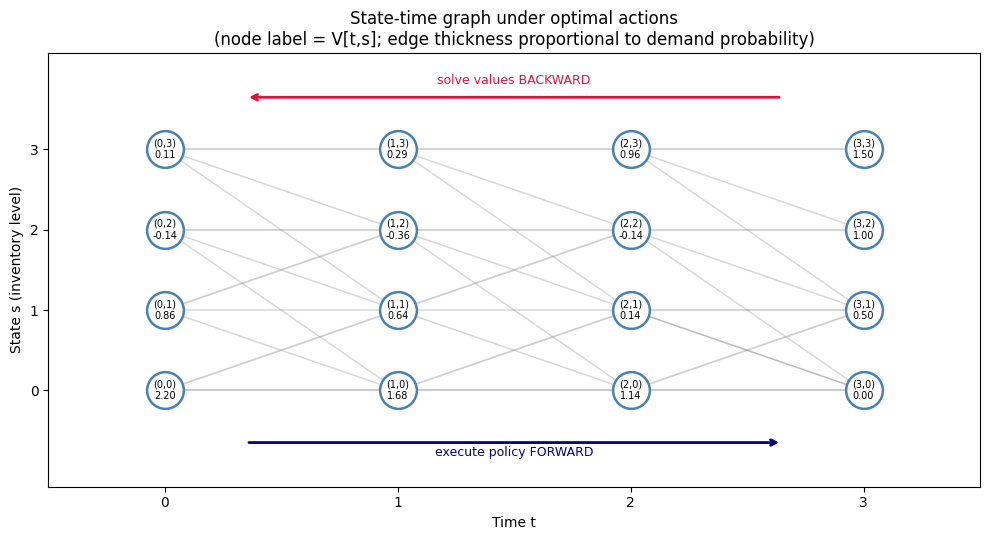

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# State-time nodes (labeled with V[t,s])
for t in range(T + 1):
    for s in STATES:
        ax.scatter(t, s, s=700, facecolors='white', edgecolors='steelblue',
                   linewidths=1.8, zorder=3)
        ax.text(t, s, f'({t},{s})\n{V[t,s]:.2f}', ha='center', va='center',
                fontsize=7, zorder=4)

# Optimal-policy transitions
for t in range(T):
    for s in STATES:
        x_star = int(PI[t, s])
        for d, p in zip(DEMAND_SUPPORT, DEMAND_PROBS):
            ns = transition(int(s), x_star, int(d))
            ax.plot([t, t + 1], [s, ns], color='grey',
                    alpha=0.10 + 0.70 * float(p),
                    linewidth=0.6 + 1.6 * float(p), zorder=1)

# Direction arrows
ax.annotate('', xy=(0.35, S_MAX + 0.65), xytext=(T - 0.35, S_MAX + 0.65),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2.0))
ax.text(T / 2, S_MAX + 0.82, 'solve values BACKWARD',
        ha='center', color='crimson', fontsize=9)

ax.annotate('', xy=(T - 0.35, -0.65), xytext=(0.35, -0.65),
            arrowprops=dict(arrowstyle='->', color='navy', lw=2.0))
ax.text(T / 2, -0.82, 'execute policy FORWARD',
        ha='center', color='navy', fontsize=9)

ax.set_xlim(-0.5, T + 0.5)
ax.set_ylim(-1.2, S_MAX + 1.2)
ax.set_xticks(range(T + 1))
ax.set_yticks(STATES)
ax.set_xlabel('Time t')
ax.set_ylabel('State s (inventory level)')
ax.set_title('State-time graph under optimal actions\n'
             '(node label = V[t,s]; edge thickness proportional to demand probability)')
plt.tight_layout()
plt.show()

We can also print illustrate the graph comprising the optimal actions.

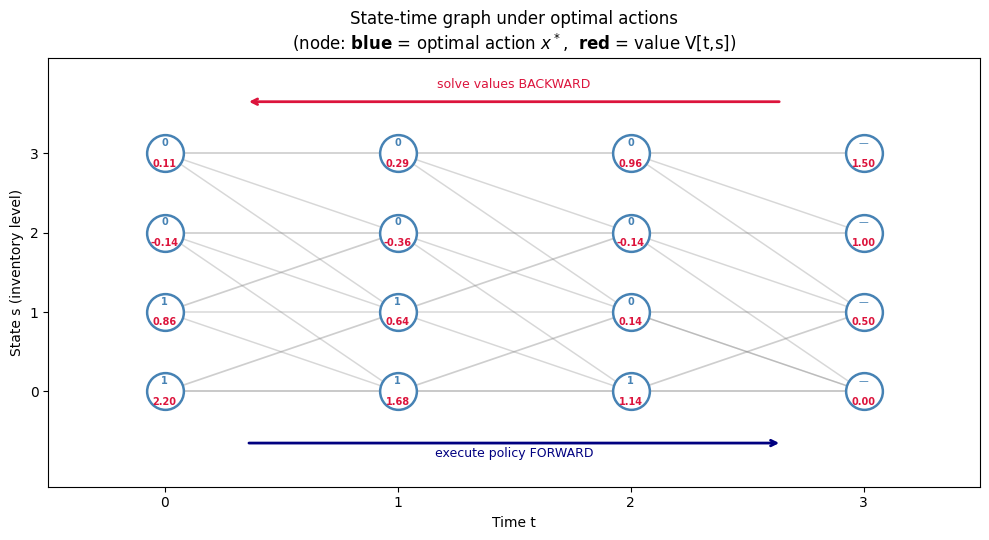

In [31]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# State-time nodes — optimal action in blue, value in red
for t in range(T + 1):
    for s in STATES:
        ax.scatter(t, s, s=700, facecolors='white', edgecolors='steelblue',
                   linewidths=1.8, zorder=3)

        # Top line: optimal action (blue) — terminal column has no action
        if t < T:
            ax.text(t, s + 0.13,
                    #f'x*={PI[t, s]}',
                    f'{PI[t, s]}',
                    ha='center', va='center',
                    fontsize=7, color='steelblue', fontweight='bold', zorder=4)
        else:
            ax.text(t, s + 0.13,
                    '—',
                    ha='center', va='center',
                    fontsize=7, color='steelblue', zorder=4)

        # Bottom line: value (red)
        ax.text(t, s - 0.13,
                f'{V[t, s]:.2f}',
                ha='center', va='center',
                fontsize=7, color='crimson', fontweight='bold', zorder=4)

# Optimal-policy transitions
for t in range(T):
    for s in STATES:
        x_star = int(PI[t, s])
        for d, p in zip(DEMAND_SUPPORT, DEMAND_PROBS):
            ns = transition(int(s), x_star, int(d))
            ax.plot([t, t + 1], [s, ns], color='grey',
                    alpha=0.10 + 0.70 * float(p),
                    linewidth=0.6 + 1.6 * float(p), zorder=1)

# Direction arrows
ax.annotate('', xy=(0.35, S_MAX + 0.65), xytext=(T - 0.35, S_MAX + 0.65),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2.0))
ax.text(T / 2, S_MAX + 0.82, 'solve values BACKWARD',
        ha='center', color='crimson', fontsize=9)

ax.annotate('', xy=(T - 0.35, -0.65), xytext=(0.35, -0.65),
            arrowprops=dict(arrowstyle='->', color='navy', lw=2.0))
ax.text(T / 2, -0.82, 'execute policy FORWARD',
        ha='center', color='navy', fontsize=9)

ax.set_xlim(-0.5, T + 0.5)
ax.set_ylim(-1.2, S_MAX + 1.2)
ax.set_xticks(range(T + 1))
ax.set_yticks(STATES)
ax.set_xlabel('Time t')
ax.set_ylabel('State s (inventory level)')
ax.set_title('State-time graph under optimal actions\n'
             r'(node: $\bf{blue}$ = optimal action $x^*$,  $\bf{red}$ = value V[t,s])')
plt.tight_layout()
plt.show()


## Section 8 — Simulating the optimal policy

The backward induction produces the policy table `pi[t, s]`.
Executing it forward is straightforward:

1. Observe current state $s_t$.
2. Look up $\pi[t, s_t]$ and place that order.
3. Observe demand $D_{t+1}$.
4. Compute next inventory $s_{t+1}$.
5. Repeat until the horizon.

We simulate a few individual trajectories to make this concrete.

Rollout 1   total cost = 3.100
  states : [0, 0, 0, 1]
  actions: [1, 1, 1]
  demands: [2, 1, 0]
  costs  : [1.5, -0.5, 1.6]  + terminal 0.500

Rollout 2   total cost = 0.500
  states : [0, 0, 0, 0]
  actions: [1, 1, 1]
  demands: [1, 1, 2]
  costs  : [-0.5, -0.5, 1.5]  + terminal 0.000

Rollout 3   total cost = 3.600
  states : [0, 0, 1, 0]
  actions: [1, 1, 0]
  demands: [2, 0, 2]
  costs  : [1.5, 1.6, 0.5]  + terminal 0.000



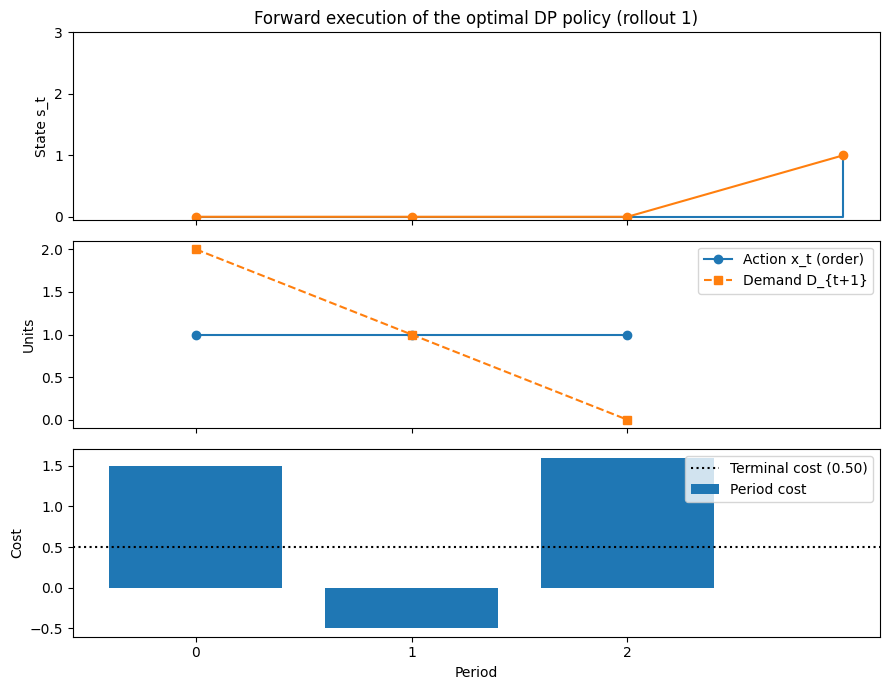

In [13]:
def simulate_trajectory(policy_fn, seed, s0=0):
    """Simulate one trajectory under a given policy."""
    rng = np.random.default_rng(seed)
    s   = s0
    state_path  = [s]
    action_path, demand_path, cost_path = [], [], []
    for t in range(T):
        x = int(policy_fn(s, t))
        d = int(rng.choice(DEMAND_SUPPORT, p=DEMAND_PROBS))
        c = immediate_cost(s, x, d)
        s = transition(s, x, d)
        action_path.append(x)
        demand_path.append(d)
        cost_path.append(c)
        state_path.append(s)
    term = terminal_value(s)
    return dict(state_path=np.array(state_path), action_path=np.array(action_path),
                demand_path=np.array(demand_path), cost_path=np.array(cost_path),
                terminal=term, total=np.sum(cost_path) + term)


def dp_policy(s, t):
    return int(PI[t, s])


# Print three sample rollouts
rollouts = [simulate_trajectory(dp_policy, seed=SEED + k) for k in range(3)]
for i, r in enumerate(rollouts, 1):
    print(f'Rollout {i}   total cost = {r["total"]:.3f}')
    print(f'  states : {r["state_path"].tolist()}')
    print(f'  actions: {r["action_path"].tolist()}')
    print(f'  demands: {r["demand_path"].tolist()}')
    print(f'  costs  : {np.round(r["cost_path"], 3).tolist()}  + terminal {r["terminal"]:.3f}')
    print()

# Detailed plot for rollout 1
r = rollouts[0]
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

axes[0].step(range(T + 1), r['state_path'], where='post', linewidth=1.5)
axes[0].plot(range(T + 1), r['state_path'], marker='o')
axes[0].set_ylabel('State s_t')
axes[0].set_yticks(STATES)
axes[0].set_title('Forward execution of the optimal DP policy (rollout 1)')

axes[1].plot(range(T), r['action_path'], marker='o', label='Action x_t (order)')
axes[1].plot(range(T), r['demand_path'], marker='s', linestyle='--', label='Demand D_{t+1}')
axes[1].set_ylabel('Units')
axes[1].legend()

axes[2].bar(range(T), r['cost_path'], label='Period cost')
axes[2].axhline(r['terminal'], linestyle=':', color='black',
                label=f'Terminal cost ({r["terminal"]:.2f})')
axes[2].set_ylabel('Cost')
axes[2].set_xlabel('Period')
axes[2].set_xticks(range(T))
axes[2].legend()

plt.tight_layout()
plt.show()

## Section 9 — Compare optimal policy to a simple baseline

We define a simple heuristic baseline:

> **Order-if-below-2 rule**: if current inventory is strictly below 2, place an order of 1 unit (the only positive action available); otherwise order nothing.

This rule is intuitive but does not solve the Bellman recursion.
It ignores how many periods remain, the cost balance between ordering, holding, shortage and sales revenue, and the terminal condition.

We compare the two policies on the **same large batch of demand paths** (common random numbers) to eliminate sampling noise.

**Key teaching point:** in a fully enumerable model, DP gives the exact optimal benchmark.
The cost gap quantifies precisely what optimality is worth.


Optimal DP policy        : mean net cost = 2.172  (95% CI +/- 0.035)
Order-if-below-2 rule    : mean net cost = 2.432  (95% CI +/- 0.042)
Gap (heuristic - DP)     : 0.260


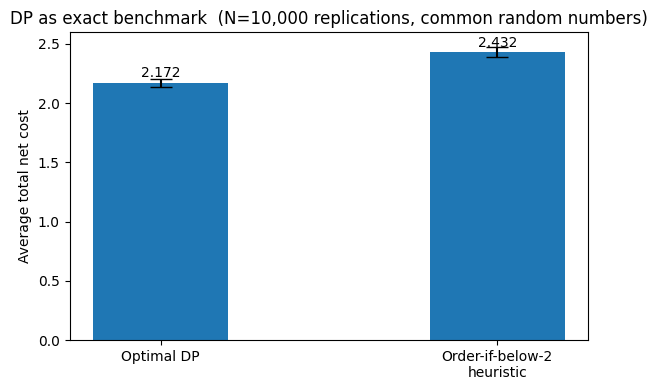

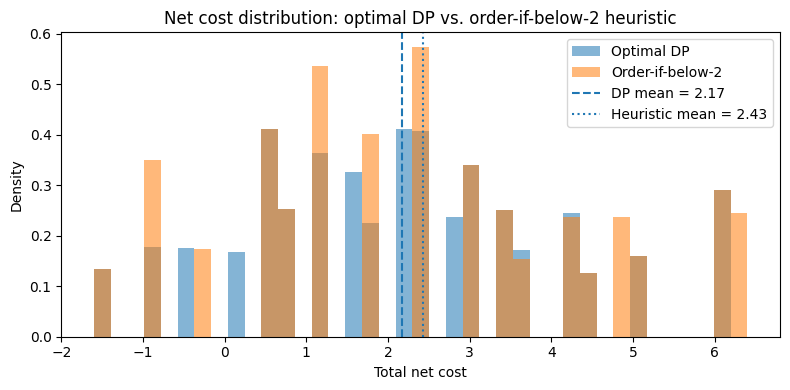

In [14]:
def order_if_below_2_policy(s, t):
    # Heuristic: order 1 unit whenever inventory is strictly below 2, else order nothing
    # (The only feasible positive action is x=1, so max action = 1.)
    x = 1 if s < 2 else 0
    x = min(x, S_MAX - s)   # respect capacity constraint
    return x


def evaluate_on_batch(policy_fn, demand_batch, s0=0):
    # Evaluate a policy over a pre-drawn batch of demand paths
    totals = []
    for demand_path in demand_batch:
        s, cost = s0, 0.0
        for t, d in enumerate(demand_path):
            x     = int(policy_fn(s, int(t)))
            cost += immediate_cost(s, x, int(d))
            s     = transition(s, x, int(d))
        cost += terminal_value(s)
        totals.append(cost)
    return np.array(totals)


rng_batch    = np.random.default_rng(SEED + 999)
N_REPS       = 10_000
demand_batch = rng_batch.choice(DEMAND_SUPPORT, size=(N_REPS, T), p=DEMAND_PROBS)

dp_costs   = evaluate_on_batch(dp_policy,               demand_batch)
heur_costs = evaluate_on_batch(order_if_below_2_policy, demand_batch)

dp_mean    = dp_costs.mean()
heur_mean  = heur_costs.mean()
dp_se      = dp_costs.std(ddof=1)   / np.sqrt(N_REPS)
heur_se    = heur_costs.std(ddof=1) / np.sqrt(N_REPS)

print(f'Optimal DP policy        : mean net cost = {dp_mean:.3f}  (95% CI +/- {1.96*dp_se:.3f})')
print(f'Order-if-below-2 rule    : mean net cost = {heur_mean:.3f}  (95% CI +/- {1.96*heur_se:.3f})')
print(f'Gap (heuristic - DP)     : {heur_mean - dp_mean:.3f}')

assert dp_mean <= heur_mean + 3 * dp_se

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Optimal DP', 'Order-if-below-2\nheuristic'],
              [dp_mean, heur_mean],
              yerr=[1.96 * dp_se, 1.96 * heur_se],
              capsize=8, width=0.4)
for bar, m in zip(bars, [dp_mean, heur_mean]):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 0.02,
            f'{m:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Average total net cost')
ax.set_title(f'DP as exact benchmark  (N={N_REPS:,} replications, common random numbers)')
plt.tight_layout()
plt.show()

# Cost distribution overlay
bins = np.linspace(min(dp_costs.min(), heur_costs.min()) - 0.1,
                   max(dp_costs.max(), heur_costs.max()) + 0.1, 40)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dp_costs,   bins=bins, alpha=0.55, label='Optimal DP',          density=True)
ax.hist(heur_costs, bins=bins, alpha=0.55, label='Order-if-below-2', density=True)
ax.axvline(dp_mean,   linestyle='--', label=f'DP mean = {dp_mean:.2f}')
ax.axvline(heur_mean, linestyle=':',  label=f'Heuristic mean = {heur_mean:.2f}')
ax.set_xlabel('Total net cost')
ax.set_ylabel('Density')
ax.set_title('Net cost distribution: optimal DP vs. order-if-below-2 heuristic')
ax.legend()
plt.tight_layout()
plt.show()


## Section 10 — Connecting the ideas

| Concept | What it means | In this notebook |
| --- | --- | --- |
| **State** | where the system is right now | inventory level $s_t \in \{0,1,2,3\}$ |
| **Action** | current decision | order quantity $x_t \in \{0,1\}$ |
| **Bellman equation** | net immediate cost + best expected future value | $V_t(s) = \min_x \mathbb{E}[c(s,x,D) + V_{t+1}(s')]$ |
| **Value function** | best achievable downstream performance | table `V[t, s]` |
| **Backward induction** | fill the value table from terminal time back to $t=0$ | the backward `for` loop in `solve_dp()` |
| **Policy** | action that wins the Bellman comparison at each $(t,s)$ | table `pi[t, s]` |

### One-step mnemonic

$$\underbrace{V_t(s)}_{\text{how good is this position}} = \min_x \left[\underbrace{\mathbb{E}[c(s,x,D)]}_{\substack{\text{pay now (net)} \\ \text{orders + holding + shortage} \\ \text{minus sales revenue}}} + \underbrace{\mathbb{E}[V_{t+1}(s')]}_{\text{best future from here}}\right]$$

### Two-direction mnemonic

$$\xleftarrow{\text{solve backward}} \quad T \to T-1 \to \cdots \to 0$$
$$\xrightarrow{\text{execute forward}} \quad 0 \to 1 \to \cdots \to T$$


## Section 11 — Final takeaway

1. **Dynamic programming solves finite-horizon sequential problems backward.**
   Starting from a known terminal value, it fills the value table layer by layer toward $t=0$.

2. **The Bellman equation is the recursion that makes this possible.**
   It decomposes today's decision into an immediate cost and an already-known future value.

3. **The value function scores positions, not trajectories.**
   $V_t(s)$ is the best achievable _expected_ total cost from that state and time.
   It is not a realized cost from any single sample path.

4. **The policy is extracted from the Bellman minimizer.**
   At each $(t, s)$, we record the action that wins the Bellman comparison.
   At execution time, only a table lookup is needed.

5. **One Bellman calculation fills one cell. Backward induction fills the whole table.**
   Understanding the local-to-global structure is the key conceptual step.

6. **In a tiny model like this, DP gives an exact optimal benchmark.**
   In larger real-world problems we cannot always compute this exactly, but the Bellman equation still defines what optimality means.